In [42]:
import os 
import config
from langgraph.graph import START, END, StateGraph, MessagesState
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, BaseMessage, RemoveMessage
from langgraph.checkpoint.memory import InMemorySaver

In [43]:
os.environ["OPENAI_API_KEY"] = config.api_key

In [44]:
class State(MessagesState):
    summary: str

In [45]:
chat = ChatOpenAI(model = "gpt-4o-mini",
                  seed = 365,
                  temperature = 0,
                  max_completion_tokens = 100)

In [46]:
def ask_question(state: State) -> State:

    print(f"\n------------> ENTERING ask_question")

    question = "あなたの質問は何ですか？"
    print(question)

    return State(messages = [AIMessage(question), HumanMessage(input())])

In [47]:
def chatbot(state: State) -> State:

    print(f"\n---------> ENTERING chatbot:")

    system_message = f'''
    ここに要約されたぶんがある。 :
    {state.get("summary", "")}

    この要約された文を参考に、次の質問には答えて。
    '''

    response = chat.invoke([SystemMessage(system_message)] + state["messages"])
    response.pretty_print()

    return State(messages = [response])

In [48]:
def summarize_and_delete_messages(state: State) -> State:
    print(f"\n----------> ENTERING trim_messages:")

    new_conversation = ""
    for i in state["messages"]:
        new_conversation += f"{i.type}: {i.content}\n\n"

    summary_instructions = f'''
以下の新しい会話内容を取り入れて、現在の要約を更新してください。
以前の要約を繰り返すのではなく、その内容を土台として発展させ、
最新の文脈や進展が反映された要約にしてください。
出力は要約のみにしてください。

以前の要約:
{state.get("summary", "")}

新しい会話:
{new_conversation}
'''
    
    print(summary_instructions)
    
    summary = chat.invoke([HumanMessage(summary_instructions)])
    
    remove_messages = [RemoveMessage(i.id) for i in state["messages"][:]]

    return State(messages = remove_messages, summary = summary.content)

In [49]:
graph = StateGraph(State)

In [50]:
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("summarize_and_delete_messages", summarize_and_delete_messages)

graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "summarize_and_delete_messages")
graph.add_edge("summarize_and_delete_messages", END)

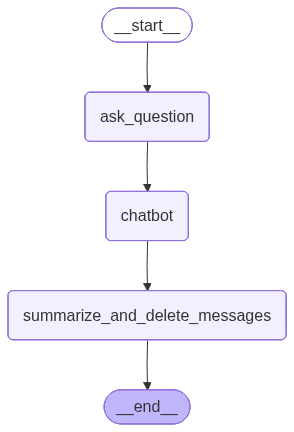

In [51]:
checkpointer = InMemorySaver()
graph_compiled = graph.compile(checkpointer)
graph_compiled

In [52]:
config1 = {"configurable":{"thread_id":"1"}}
config2 = {"configurable":{"thread_id":"2"}}

In [56]:
graph_compiled.invoke(State(), config2)


------------> ENTERING ask_question
あなたの質問は何ですか？


 詩人はいつ生まれたの？



---------> ENTERING chatbot:
================================== Ai Message ==================================

詩人について具体的に誰を指しているのか教えていただければ、その詩人の生年月日についてお答えできます。

----------> ENTERING trim_messages:

以下の新しい会話内容を取り入れて、現在の要約を更新してください。
以前の要約を繰り返すのではなく、その内容を土台として発展させ、
最新の文脈や進展が反映された要約にしてください。
出力は要約のみにしてください。

以前の要約:


新しい会話:
ai: あなたの質問は何ですか？

human: 詩人はいつ生まれたの？

ai: 詩人について具体的に誰を指しているのか教えていただければ、その詩人の生年月日についてお答えできます。





{'messages': [],
 'summary': '詩人の生年月日についての質問があり、AIは具体的な詩人の名前を尋ねて、その情報を提供する準備をしています。これにより、会話は詩人に関する詳細な情報を得る方向に進んでいます。'}